In [2]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os

# Ruta a la carpeta pr1 (ajusta si es necesario)
path_pr1 = "./pr1/" 

# Listamos los archivos para verificar
files = sorted(glob.glob(os.path.join(path_pr1, "*.nc")))
print(f"Se encontraron {len(files)} archivos en {path_pr1}")
for f in files:
    print(os.path.basename(f))

Se encontraron 8 archivos en ./pr1/
pr_CHP12_CNRM-ESM2-1_historical_r1i1p1f2_CNRM-ALADIN64_v1_day_19500101-19781231_chile.nc
pr_CHP12_CNRM-ESM2-1_historical_r1i1p1f2_CNRM-ALADIN64_v1_day_19790101-20141231_chile.nc
pr_CHP12_CNRM-ESM2-1_ssp370_r1i1p1f2_CNRM-ALADIN64_v1_day_20150101-20391231_chile.nc
pr_CHP12_CNRM-ESM2-1_ssp370_r1i1p1f2_CNRM-ALADIN64_v1_day_20400101-20641231_chile.nc
pr_CHP12_CNRM-ESM2-1_ssp370_r1i1p1f2_CNRM-ALADIN64_v1_day_20650101-21001231_chile.nc
pr_CHP12_CNRM-ESM2-1_ssp585_r1i1p1f2_CNRM-ALADIN64_v1_day_20150101-20391231_chile.nc
pr_CHP12_CNRM-ESM2-1_ssp585_r1i1p1f2_CNRM-ALADIN64_v1_day_20400101-20641231_chile.nc
pr_CHP12_CNRM-ESM2-1_ssp585_r1i1p1f2_CNRM-ALADIN64_v1_day_20650101-21001231_chile.nc


---

## 2. Unión de la Serie Histórica y Proyecciones
A diferencia de CR2MET, aquí tienes que decidir qué "futuro" quieres analizar (SSP370 o SSP585). Vamos a crear una función que cargue la serie completa (Histórica + Escenario).

In [3]:
def load_katerina_scenario(scenario_name="ssp585"):
    """
    Carga los archivos históricos y los concatena con el escenario elegido.
    """
    # Archivos históricos (1950-2014)
    hist_files = [f for f in files if "historical" in f]
    
    # Archivos del escenario (2015-2100)
    scen_files = [f for f in files if scenario_name in f]
    
    # Unimos las listas y cargamos con xarray
    all_files = hist_files + scen_files
    
    # Abrimos todos los archivos concatenándolos en la dimensión tiempo
    ds_kat = xr.open_mfdataset(all_files, concat_dim="time", combine="nested")
    
    # Aseguramos que las unidades de pr sean consistentes (suelen venir en kg/m2/s o mm/day)
    # Si es necesario, convertimos aquí.
    return ds_kat

# Cargamos el escenario SSP5-8.5 (el más extremo)
ds_kat = load_katerina_scenario("ssp585")
print("\nDataset cargado correctamente:")
print(ds_kat)


Dataset cargado correctamente:
<xarray.Dataset> Size: 65GB
Dimensions:      (time: 55152, y: 255, x: 68, nvertex: 4, axis_nbounds: 2)
Coordinates:
  * time         (time) datetime64[ns] 441kB 1950-01-01T12:00:00 ... 2100-12-...
    lat          (y, x) float64 139kB dask.array<chunksize=(255, 68), meta=np.ndarray>
    lon          (y, x) float64 139kB dask.array<chunksize=(255, 68), meta=np.ndarray>
Dimensions without coordinates: y, x, nvertex, axis_nbounds
Data variables:
    bounds_lat   (time, y, x, nvertex) float64 31GB dask.array<chunksize=(10592, 255, 68, 4), meta=np.ndarray>
    bounds_lon   (time, y, x, nvertex) float64 31GB dask.array<chunksize=(10592, 255, 68, 4), meta=np.ndarray>
    pr           (time, y, x) float32 4GB dask.array<chunksize=(1, 255, 68), meta=np.ndarray>
    time_bounds  (time, axis_nbounds) datetime64[ns] 882kB dask.array<chunksize=(1, 2), meta=np.ndarray>
Attributes: (12/30)
    description:                                      Created by xios
    Conven

C:\Users\pgome\AppData\Local\Temp\ipykernel_8464\3689628994.py:15: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds_kat = xr.open_mfdataset(all_files, concat_dim="time", combine="nested")


In [7]:
import numpy as np
import pandas as pd

# 1. Coordenadas de Santiago
lat_target, lon_target = -33.45, -70.66

# 2. Encontrar índices (y, x) más cercanos
# Calculamos la distancia usando las coordenadas 2D 'lat' y 'lon'
dist = np.sqrt((ds_kat.lat - lat_target)**2 + (ds_kat.lon - lon_target)**2)
indices = dist.argmin(dim=["y", "x"])

# 3. Extraer la serie y convertir a mm/día
# Seleccionamos por índice (isel) y cargamos en memoria (.compute)
stgo_series = ds_kat["pr"].isel(y=indices["y"], x=indices["x"]).compute()

# Crear DataFrame
df_kat = stgo_series.to_dataframe()[["pr"]]

# 4. Conversión de unidades (de kg/m2/s a mm/día)
# Multiplicamos por 86400 (segundos en un día)
df_kat["pr"] = df_kat["pr"] * 86400

# 5. Limpieza de "llovizna" (Drizzle effect)
# Aplicamos el umbral de 1mm para definir un día seco real
df_kat["pr"] = np.where(df_kat["pr"] < 1.0, 0, df_kat["pr"])

print("Serie de Santiago (Katerina) lista:")
print(df_kat.describe())

Serie de Santiago (Katerina) lista:
                 pr
count  55152.000000
mean       3.756280
std       10.799019
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max      197.353561


---

## 2. Detección de Dry Spells y Tendencias (5-year Rolling)
Ahora aplicamos la misma lógica que usamos en CR2MET para ver la evolución histórica y futura.

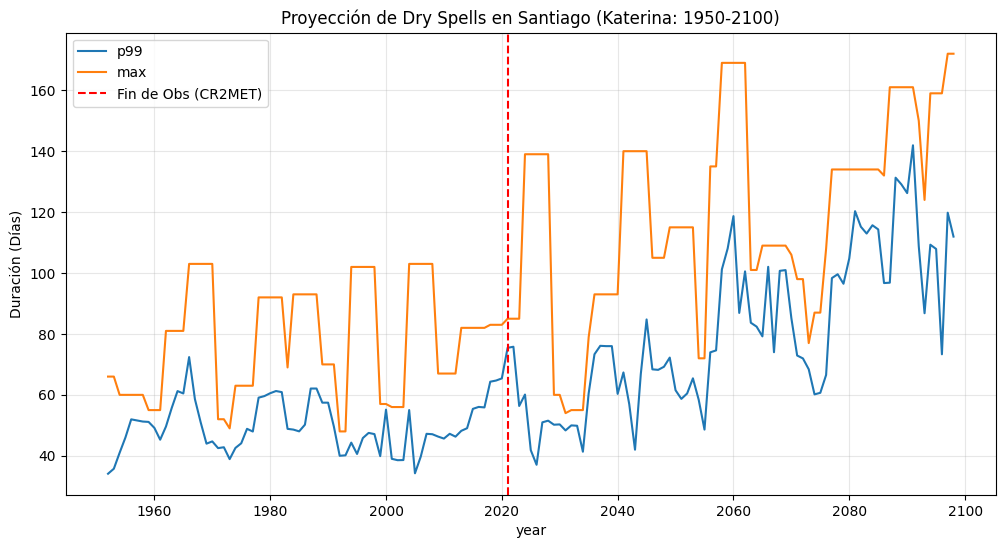

In [8]:
# Función para detectar rachas (la que ya teníamos)
def get_dry_spells(series):
    is_dry = series < 1.0
    tokens = is_dry.astype(int).diff().fillna(0)
    starts = np.where(tokens == 1)[0]
    ends = np.where(tokens == -1)[0]
    if is_dry.iloc[0]: starts = np.insert(starts, 0, 0)
    if is_dry.iloc[-1]: ends = np.append(ends, len(series)-1)
    durations = ends - starts
    return pd.DataFrame({"start": series.index[starts], "duration": durations})

# Calculamos las rachas
df_spells_kat = get_dry_spells(df_kat["pr"])
df_spells_kat["year"] = df_spells_kat["start"].dt.year

# Cálculo de métricas en ventanas móviles de 5 años (1950-2100)
results = []
years = np.arange(1950, 2097)

for y in years:
    mask = (df_spells_kat["year"] >= y) & (df_spells_kat["year"] <= y+4)
    data = df_spells_kat.loc[mask, "duration"]
    if not data.empty:
        results.append({
            "year": y + 2,
            "p99": np.percentile(data, 99),
            "max": data.max(),
            "mean": data.mean()
        })

df_trends_kat = pd.DataFrame(results).set_index("year")

# Graficar la tendencia de largo plazo
df_trends_kat[["p99", "max"]].plot(figsize=(12,6), title="Proyección de Dry Spells en Santiago (Katerina: 1950-2100)")
plt.axvline(x=2021, color='r', linestyle='--', label='Fin de Obs (CR2MET)')
plt.ylabel("Duración (Días)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()